In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pubchempy as pcp
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor

from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, rdPartialCharges
from rdkit.Chem.MolStandardize import rdMolStandardize

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

DATA_PATH = "../data/Data.csv"
TARGET_COL = "Removal %"
TIME_COL = "Rxn Time (min)"
DYE_COL = "Dye"

CORR_THRESHOLD = 0.88


In [21]:
df = pd.read_csv(DATA_PATH)

if DYE_COL not in df.columns:
    raise KeyError(f"Missing column: {DYE_COL}")

df[DYE_COL] = df[DYE_COL].astype(str).str.strip()

print("Shape:", df.shape)
display(df.head())


Shape: (162, 3)


,Dye,Rxn Time (min),Removal %
0,MB,0,0.000000
1,MB,5,0.630870
2,MB,10,0.665654
3,MB,15,0.707449
4,MB,20,0.742452


In [22]:
dye_name_map = {
    "MB": "Methylene Blue",
    "MO": "Methyl Orange",
    "Tart": "Tartrazine",
    "RhB": "Rhodamine B",
    "R6G": "Rhodamine 6G",
    "Am": "Amaranth",
    "CV": "Crystal Violet",
    "MaG": "Malachite Green",
    "Ab": "Amido Black 10B",
    "PonS": "Ponceau S",
    "BBR": "Coomassie Brilliant Blue R-250",
    "BBG": "Coomassie Brilliant Blue G-250",
    "CB": "Cibacron Blue 3GA",
    "BPB": "Bromophenol Blue",
    "Erio": "Erioglaucine",
    "Reso": "Resorufin",
    "DR80": "Direct Red 80",
    "Congo": "Congo Red",
    "DMMB": "Dimethylmethylene Blue",
    "BF": "Basic Fuchsin",
    "Fl": "Fluorescein",
    "NBA": "Nile Blue A",
    "OG": "Orange G",
    "CS-3B": "Crocein Scarlet 3B",
    "FBMBSN": "Solvent Blue 38",
    "MG": "Methyl green chloride",
    "BCB": "Brilliant Cresyl Blue ALD",
}

unique_dyes = df[DYE_COL].dropna().unique().tolist()

missing_names = [x for x in unique_dyes if x not in dye_name_map]

print("Unique dyes:", len(unique_dyes))

if missing_names:
    print("Missing names:", missing_names)


Unique dyes: 27


In [23]:
def fetch_smiles_from_pubchem(dye_code):
    """Fetch canonical SMILES."""
    name = dye_name_map.get(str(dye_code).strip())

    if name is None:
        return None

    try:
        compounds = pcp.get_compounds(name, namespace="name")

        if not compounds:
            print(f"[PUBCHEM FAILED] {dye_code} -> {name}")
            return None

        return compounds[0].canonical_smiles

    except Exception as exc:
        print(f"[PUBCHEM ERROR] {dye_code}: {exc}")
        return None


def standardize_parent_mol(smiles):
    """Remove small counterions and keep the main fragment."""
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    chooser = rdMolStandardize.LargestFragmentChooser()
    parent = chooser.choose(mol)

    Chem.SanitizeMol(parent)
    return parent


In [24]:
def get_gasteiger_descriptors(mol):
    """Calculate compact Gasteiger descriptors."""
    mol_h = Chem.AddHs(Chem.Mol(mol))
    rdPartialCharges.ComputeGasteigerCharges(mol_h)

    charges = []
    carbon_charges = []

    for atom in mol_h.GetAtoms():
        try:
            q = float(atom.GetProp("_GasteigerCharge"))
        except (KeyError, ValueError):
            continue

        if not np.isfinite(q):
            continue

        charges.append(q)

        if atom.GetSymbol() == "C":
            carbon_charges.append(q)

    if not charges:
        return {
            "Gasteiger_qC_Min": np.nan,
            "Gasteiger_Charge_Range": np.nan,
        }

    return {
        "Gasteiger_qC_Min": (
            min(carbon_charges)
            if carbon_charges
            else np.nan
        ),
        "Gasteiger_Charge_Range": max(charges) - min(charges),
    }


def count_element(mol, symbol):
    return sum(
        atom.GetSymbol() == symbol
        for atom in mol.GetAtoms()
    )


def count_azo_groups(mol):
    pattern = Chem.MolFromSmarts("[#7]=[#7]")
    return len(mol.GetSubstructMatches(pattern))


def conjugated_bond_fraction(mol):
    n_bonds = mol.GetNumBonds()

    if n_bonds == 0:
        return 0.0

    n_conjugated = sum(
        bond.GetIsConjugated()
        for bond in mol.GetBonds()
    )

    return n_conjugated / n_bonds


In [25]:
CURATED_FEATURES = [
    "Gasteiger_qC_Min",
    "Gasteiger_Charge_Range",
    "Conjugated_Bond_Fraction",
    "MW",
    "TPSA",
    "LogP",
    "Aromatic_Rings",
    "Fraction_Csp3",
    "Azo_Count",
    "Sulfur_Count",
]


def extract_chemical_features(dye_list):
    """Build a compact descriptor table."""
    rows = []

    for dye_code in dye_list:
        dye_code = str(dye_code).strip()
        print("Processing:", dye_code)

        smiles = fetch_smiles_from_pubchem(dye_code)

        if not smiles:
            continue

        mol = standardize_parent_mol(smiles)

        if mol is None:
            print(f"[RDKIT FAILED] {dye_code}")
            continue

        row = {
            "Dye": dye_code,
            "Full_Name": dye_name_map[dye_code],
            "SMILES": smiles,
            "Parent_SMILES": Chem.MolToSmiles(mol),

            "MW": Descriptors.MolWt(mol),
            "TPSA": Descriptors.TPSA(mol),
            "LogP": Descriptors.MolLogP(mol),

            "Aromatic_Rings": Descriptors.NumAromaticRings(mol),
            "Fraction_Csp3": Descriptors.FractionCSP3(mol),
            "Conjugated_Bond_Fraction": conjugated_bond_fraction(mol),

            "Azo_Count": count_azo_groups(mol),
            "Sulfur_Count": count_element(mol, "S"),
        }

        row.update(get_gasteiger_descriptors(mol))
        rows.append(row)

    features = pd.DataFrame(rows)

    return features


In [26]:
dye_features = extract_chemical_features(unique_dyes)

print("Descriptor table:", dye_features.shape)
display(dye_features)


Processing: MB


[18:08:01] Running LargestFragmentChooser
[18:08:01] Fragment: CN(C)c1ccc2nc3ccc(=[N+](C)C)cc-3sc2c1
[18:08:01] New largest fragment: CN(C)c1ccc2nc3ccc(=[N+](C)C)cc-3sc2c1 (38)
[18:08:01] Fragment: [Cl-]


Processing: MO


[18:08:02] Running LargestFragmentChooser
[18:08:02] Fragment: CN(C)c1ccc(N=Nc2ccc(S(=O)(=O)[O-])cc2)cc1
[18:08:02] New largest fragment: CN(C)c1ccc(N=Nc2ccc(S(=O)(=O)[O-])cc2)cc1 (35)
[18:08:02] Fragment: [Na+]


Processing: Tart


...

Processing: BCB


[18:08:26] Running LargestFragmentChooser
[18:08:26] Fragment: CC[N+](CC)=c1ccc2nc3cc(C)c(N)cc3oc-2c1
[18:08:26] New largest fragment: CC[N+](CC)=c1ccc2nc3cc(C)c(N)cc3oc-2c1 (41)
[18:08:26] Fragment: CC[N+](CC)=c1ccc2nc3cc(C)c(N)cc3oc-2c1
[18:08:26] New largest fragment: CC[N+](CC)=c1ccc2nc3cc(C)c(N)cc3oc-2c1 (41)
[18:08:26] Fragment: [Cl][Zn-2]([Cl])([Cl])[Cl]


Processing: CS-3B
Descriptor table: (27, 14)


[18:08:28] Running LargestFragmentChooser
[18:08:28] Fragment: O=S(=O)([O-])c1cc(S(=O)(=O)[O-])c2c(N=Nc3ccc(N=Nc4ccccc4)cc3)c(O)ccc2c1
[18:08:28] New largest fragment: O=S(=O)([O-])c1cc(S(=O)(=O)[O-])c2c(N=Nc3ccc(N=Nc4ccccc4)cc3)c(O)ccc2c1 (49)
[18:08:28] Fragment: [Na+]
[18:08:28] Fragment: [Na+]


,Dye,Full_Name,SMILES,Parent_SMILES,MW,TPSA,LogP,Aromatic_Rings,Fraction_Csp3,Conjugated_Bond_Fraction,Azo_Count,Sulfur_Count,Gasteiger_qC_Min,Gasteiger_Charge_Range
0,MB,Methylene Blue,CN(C)C1=CC2=C(C=C1)N=C3C=CC(=[N+](C)C)C=C3S2.[...,CN(C)c1ccc2nc3ccc(=[N+](C)C)cc-3sc2c1,284.408,19.14,2.49890,1,0.250000,0.818182,0,1,-0.036529,0.578122
1,MO,Methyl Orange,CN(C)C1=CC=C(C=C1)N=NC2=CC=C(C=C2)S(=O)(=O)[O-...,CN(C)c1ccc(N=Nc2ccc(S(=O)(=O)[O-])cc2)cc1,304.351,85.16,3.07210,2,0.142857,0.727273,1,1,-0.042443,0.867962
2,Tart,Tartrazine,C1=CC(=CC=C1N=NC2C(=NN(C2=O)C3=CC=C(C=C3)S(=O)...,O=C([O-])C1=NN(c2ccc(S(=O)(=O)[O-])cc2)C(=O)C1...,465.401,211.92,-0.90020,2,0.062500,0.666667,1,2,-0.042508,1.024021
3,RhB,Rhodamine B,CCN(CC)C1=CC2=C(C=C1)C(=C3C=CC(=[N+](CC)CC)C=C...,CCN(CC)c1ccc2c(-c3ccccc3C(=O)O)c3ccc(=[N+](CC)...,443.567,56.69,5.56100,2,0.285714,0.777778,0,0,-0.061599,0.813440
4,R6G,Rhodamine 6G,CCNC1=CC2=C(C=C1C)C(=C3C=C(C(=[NH+]CC)C=C3O2)C...,CCNc1cc2oc3cc(=[NH+]CC)c(C)cc-3c(-c3ccccc3C(=O...,443.567,65.44,4.43114,2,0.285714,0.777778,0,0,-0.061599,0.908234
5,Am,Amaranth,C1=CC=C2C(=C1)C(=CC=C2S(=O)(=O)[O-])N=NC3=C4C=...,O=S(=O)([O-])c1ccc2c(N=Nc3ccc(S(=O)(=O)[O-])c4...,535.513,216.55,2.82630,4,0.000000,0.684211,1,3,-0.061585,1.037314
6,CV,Crystal Violet,CN(C)C1=CC=C(C=C1)C(=C2C=CC(=[N+](C)C)C=C2)C3=...,CN(C)c1ccc(C(=C2C=CC(=[N+](C)C)C=C2)c2ccc(N(C)...,372.536,9.49,4.45960,2,0.240000,0.800000,0,0,-0.052279,0.576620
7,MaG,Malachite Green,CN(C)C1=CC=C(C=C1)C(=C2C=CC(=[N+](C)C)C=C2)C3=...,CN(C)c1ccc(C(=C2C=CC(=[N+](C)C)C=C2)c2ccccc2)cc1,329.467,6.25,4.39360,2,0.173913,0.851852,0,0,-0.062225,0.576620
8,Ab,Amido Black 10B,C1=CC=C(C=C1)N=NC2=C(C3=C(C(=C(C=C3C=C2S(=O)(=...,Nc1c(N=Nc2ccc([N+](=O)[O-])cc2)c(S(=O)(=O)[O-]...,570.521,253.23,4.67480,4,0.000000,0.809524,2,2,-0.062113,1.037228
9,PonS,Ponceau S,C1=CC(=CC=C1N=NC2=CC(=C(C=C2)N=NC3=C4C=CC(=CC4...,O=S(=O)([O-])c1ccc(N=Nc2ccc(N=Nc3c(O)c(S(=O)(=...,668.621,298.47,2.99260,4,0.000000,0.652174,2,4,-0.050742,1.037315


In [27]:
available_features = [
    col for col in CURATED_FEATURES
    if col in dye_features.columns
]

constant_features = [
    col for col in available_features
    if dye_features[col].nunique(dropna=True) <= 1
]

candidate_features = [
    col for col in available_features
    if col not in constant_features
]

print("Constant features removed:", constant_features)
print("Candidate features:", candidate_features)


Constant features removed: []
Candidate features: ['Gasteiger_qC_Min', 'Gasteiger_Charge_Range', 'Conjugated_Bond_Fraction', 'MW', 'TPSA', 'LogP', 'Aromatic_Rings', 'Fraction_Csp3', 'Azo_Count', 'Sulfur_Count']


In [28]:
def correlation_prune(feature_df, feature_list, threshold=0.88):
    """Remove highly correlated descriptors by priority order."""
    corr = feature_df[feature_list].corr().abs()

    kept = []
    dropped = {}

    for feature in feature_list:
        conflict = None

        for previous in kept:
            value = corr.loc[feature, previous]

            if np.isfinite(value) and value >= threshold:
                conflict = previous
                break

        if conflict is None:
            kept.append(feature)
        else:
            dropped[feature] = {
                "correlated_with": conflict,
                "abs_r": corr.loc[feature, conflict],
            }

    return kept, dropped


selected_features, dropped_correlated = correlation_prune(
    dye_features,
    candidate_features,
    threshold=CORR_THRESHOLD
)

print("Selected features:")
for x in selected_features:
    print(" -", x)

if dropped_correlated:
    print("\nDropped for high correlation:")
    display(pd.DataFrame(dropped_correlated).T)


Selected features:
 - Gasteiger_qC_Min
 - Gasteiger_Charge_Range
 - Conjugated_Bond_Fraction
 - MW
 - TPSA
 - LogP
 - Fraction_Csp3
 - Azo_Count

Dropped for high correlation:


,correlated_with,abs_r
Aromatic_Rings,MW,0.88589
Sulfur_Count,TPSA,0.928743


In [29]:
selected_table = dye_features[
    ["Dye", "Full_Name"] + selected_features
].copy()

display(selected_table)


,Dye,Full_Name,Gasteiger_qC_Min,Gasteiger_Charge_Range,Conjugated_Bond_Fraction,MW,TPSA,LogP,Fraction_Csp3,Azo_Count
0,MB,Methylene Blue,-0.036529,0.578122,0.818182,284.408,19.14,2.49890,0.250000,0
1,MO,Methyl Orange,-0.042443,0.867962,0.727273,304.351,85.16,3.07210,0.142857,1
2,Tart,Tartrazine,-0.042508,1.024021,0.666667,465.401,211.92,-0.90020,0.062500,1
3,RhB,Rhodamine B,-0.061599,0.813440,0.777778,443.567,56.69,5.56100,0.285714,0
4,R6G,Rhodamine 6G,-0.061599,0.908234,0.777778,443.567,65.44,4.43114,0.285714,0
5,Am,Amaranth,-0.061585,1.037314,0.684211,535.513,216.55,2.82630,0.000000,1
6,CV,Crystal Violet,-0.052279,0.576620,0.800000,372.536,9.49,4.45960,0.240000,0
7,MaG,Malachite Green,-0.062225,0.576620,0.851852,329.467,6.25,4.39360,0.173913,0
8,Ab,Amido Black 10B,-0.062113,1.037228,0.809524,570.521,253.23,4.67480,0.000000,2
9,PonS,Ponceau S,-0.050742,1.037315,0.652174,668.621,298.47,2.99260,0.000000,2


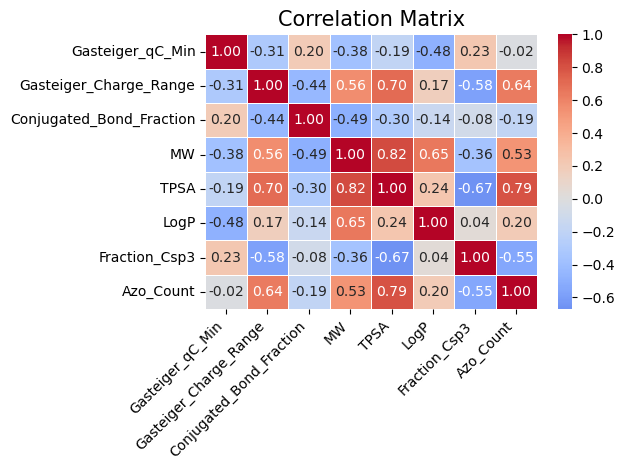

In [30]:
# CORRELATION MATRIX
corr = dye_features[selected_features].corr()

plt.figure()

ax = sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix", fontsize=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [31]:
vif_input = (
    dye_features[selected_features]
    .replace([np.inf, -np.inf], np.nan)
    .copy()
)

vif_input = vif_input.fillna(vif_input.median())

vif_table = pd.DataFrame({
    "Feature": selected_features,
    "VIF": [
        variance_inflation_factor(vif_input.values, i)
        for i in range(vif_input.shape[1])
    ]
}).sort_values("VIF", ascending=False)

display(vif_table)


,Feature,VIF
3,MW,137.023307
4,TPSA,67.087025
1,Gasteiger_Charge_Range,48.204840
0,Gasteiger_qC_Min,47.138311
5,LogP,33.322911
2,Conjugated_Bond_Fraction,29.307376
7,Azo_Count,7.832932
6,Fraction_Csp3,5.242941


In [32]:
df_model = df.merge(
    dye_features[["Dye"] + selected_features],
    on="Dye",
    how="left",
    validate="many_to_one"
)

print("Merged shape:", df_model.shape)


Merged shape: (162, 11)


In [33]:
if TARGET_COL in df_model.columns:
    cols = [
        col for col in [TARGET_COL, TIME_COL] + selected_features
        if col in df_model.columns
    ]

    target_corr = (
        df_model[cols]
        .corr(numeric_only=True)[TARGET_COL]
        .drop(TARGET_COL)
        .sort_values(key=np.abs, ascending=False)
    )

    display(target_corr.to_frame("Pearson_Correlation"))


,Pearson_Correlation
Rxn Time (min),0.832799
MW,-0.236862
TPSA,-0.191314
LogP,-0.186716
Azo_Count,-0.150244
Gasteiger_qC_Min,0.077532
Conjugated_Bond_Fraction,0.073868
Fraction_Csp3,0.066180
Gasteiger_Charge_Range,-0.045907


In [34]:
if TARGET_COL in df_model.columns and TIME_COL in df_model.columns:
    valid = df_model[[TARGET_COL, TIME_COL]].dropna().index

    time_model = RandomForestRegressor(
        n_estimators=500,
        min_samples_leaf=3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    time_model.fit(
        df_model.loc[valid, [TIME_COL]],
        df_model.loc[valid, TARGET_COL],
    )

    df_model.loc[valid, "Time_Only_Prediction"] = time_model.predict(
        df_model.loc[valid, [TIME_COL]]
    )

    df_model.loc[valid, "Time_Adjusted_Removal"] = (
        df_model.loc[valid, TARGET_COL]
        - df_model.loc[valid, "Time_Only_Prediction"]
    )

    residual_corr = (
        df_model[
            ["Time_Adjusted_Removal"] + selected_features
        ]
        .corr(numeric_only=True)["Time_Adjusted_Removal"]
        .drop("Time_Adjusted_Removal")
        .sort_values(key=np.abs, ascending=False)
    )

    display(
        residual_corr.to_frame(
            "Correlation_with_Time_Adjusted_Removal"
        )
    )


,Correlation_with_Time_Adjusted_Removal
MW,-0.474637
TPSA,-0.383366
LogP,-0.374151
Azo_Count,-0.301066
Gasteiger_qC_Min,0.155363
Conjugated_Bond_Fraction,0.148021
Fraction_Csp3,0.132616
Gasteiger_Charge_Range,-0.091992


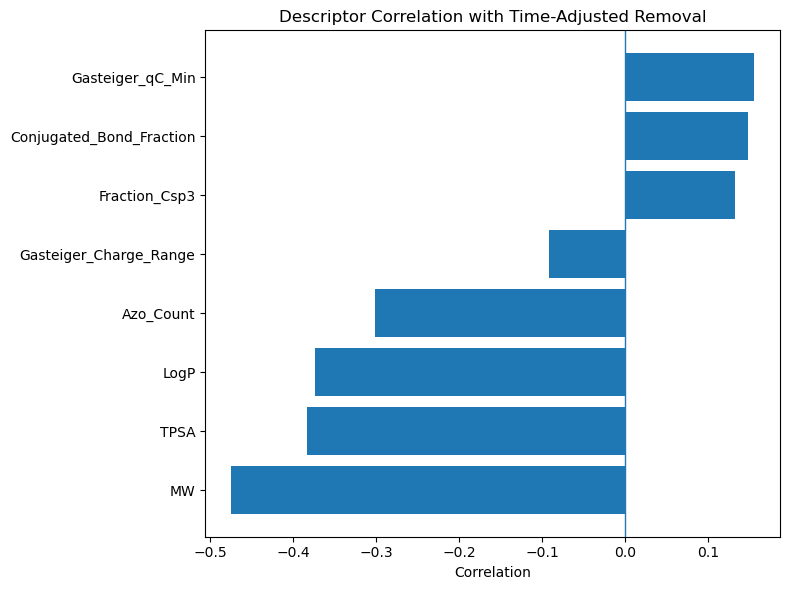

In [35]:
if "Time_Adjusted_Removal" in df_model.columns:
    plot_values = residual_corr.sort_values()

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(plot_values.index, plot_values.values)
    ax.axvline(0, linewidth=1)
    ax.set_xlabel("Correlation")
    ax.set_title("Descriptor Correlation with Time-Adjusted Removal")
    fig.tight_layout()
    plt.show()
